In [1]:
import paddle
print(paddle.device.get_device())
import cv2
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
from pathlib import Path

gpu:0


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/jko/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/jko/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/jko/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/jko/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/jko/.pad

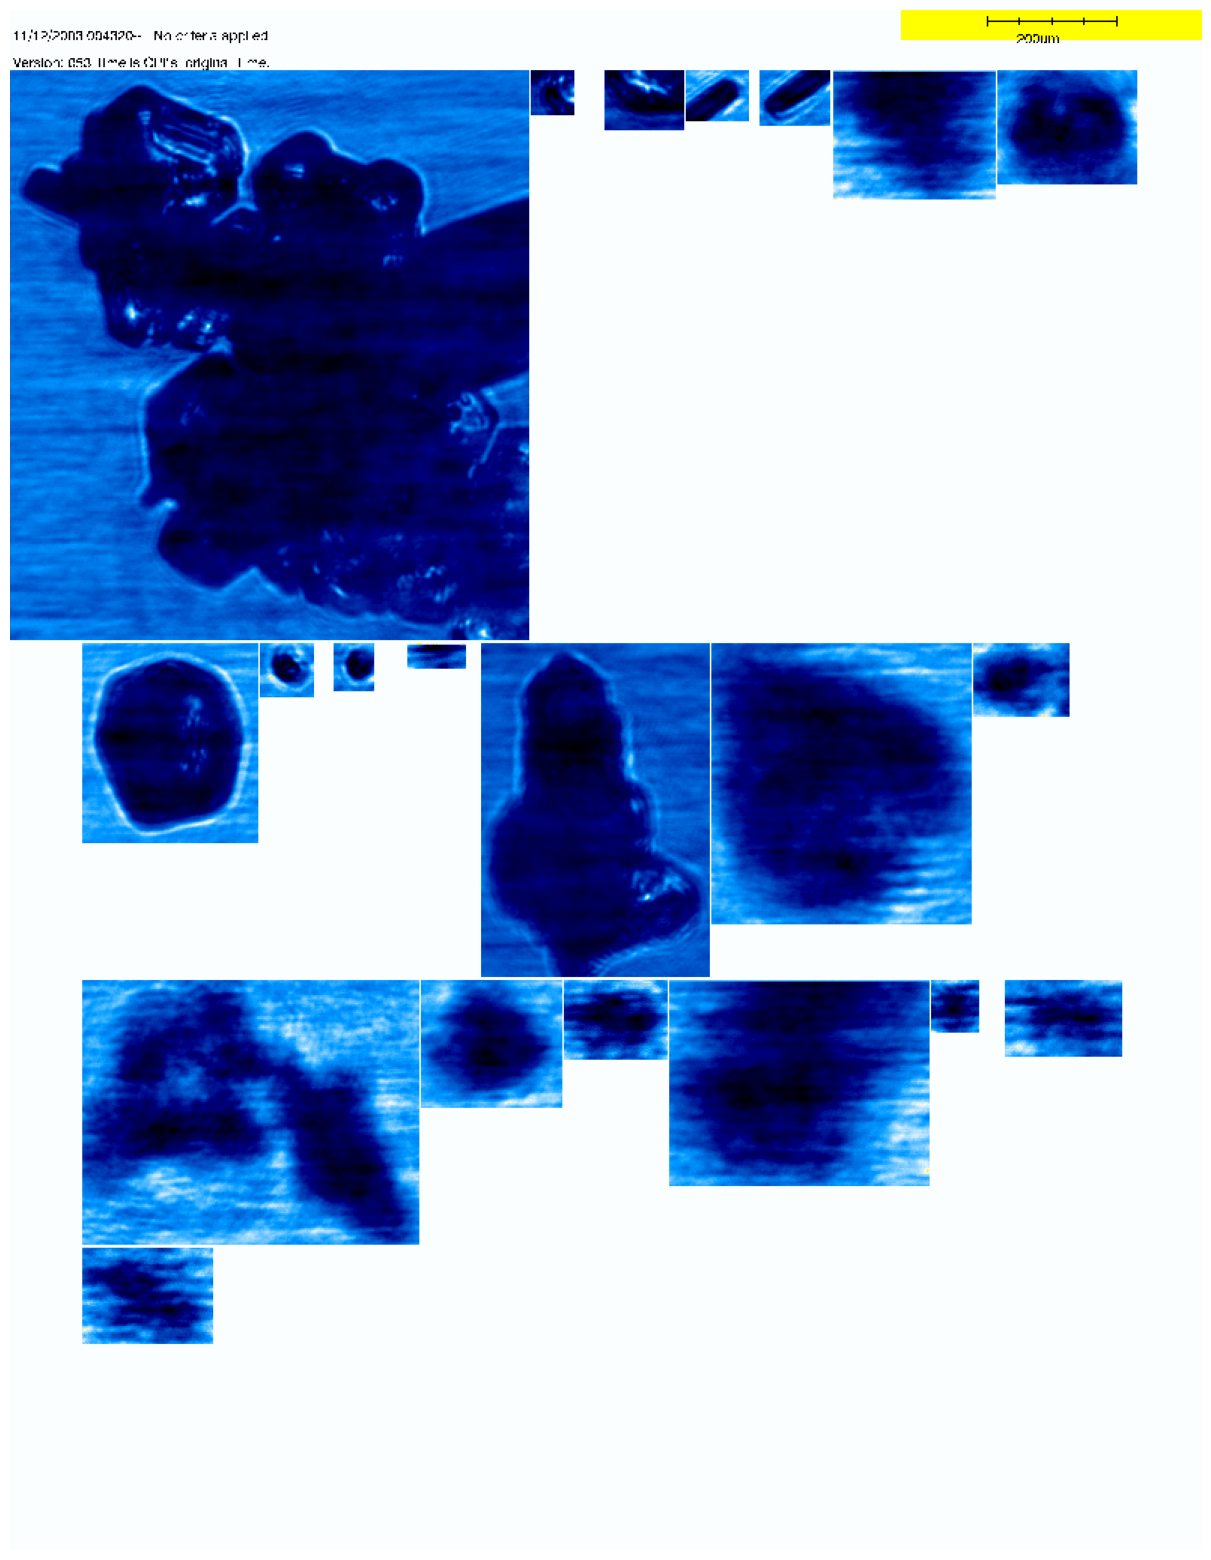

In [7]:
# 1. Specialized Init for CPI Sheets
ocr = PaddleOCR(
    device='gpu:0', 
    lang='en',
    use_textline_orientation=True,
    # 'poly' is better for irregular layouts, but 'square' is more stable for header text
    text_det_limit_type='max', 
    text_det_limit_side_len=4000,
    # Increase these to filter out the 'ghost' detections from particle edges
    text_det_thresh=0.4,       
    text_det_box_thresh=0.5,
    # Ratio for expanding detected boxes to capture full characters near edges
    text_det_unclip_ratio=2.0 
)

# 2. Load and Pre-process
img = cv2.imread("/home/vanessa/hulk/cocpit/cpi_data/campaigns/AIRS_II/sheets/2003_1112_004322_145.png")
# Convert to Grayscale to reduce 'blue noise' interference
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Invert or use RGB for Paddle
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Run Inference
results = ocr.ocr(img_rgb)

# 4. Visualization
vis = img_rgb.copy()
if results:
    for res in results:
        texts = res.get('rec_texts', [])
        scores = res.get('rec_scores', [])
        boxes = res.get('rec_polys', [])

        for text, conf, box in zip(texts, scores, boxes):
            if conf >= 0.5: # Strict confidence to avoid 'ghosts'
                pts = np.array(box, np.int32)
                cv2.polylines(vis, [pts], True, (255, 0, 0), 3)
                cv2.putText(vis, f"{text} ({conf:.2f})", (pts[0][0], pts[0][1]-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

plt.figure(figsize=(20, 20))
plt.imshow(vis)
plt.axis("off")
plt.show()
